# 07 — Spatial prediction maps

**Goal:** Generate spatial prediction maps using the trained machine learning model.

We load the dataset, train one model per target on the full data, build a 100×100 grid over the study area, interpolate features to the grid via nearest-neighbor, predict each target on the grid, and plot one map per target.

# 1. Load dataset

Load the dataset and normalize column names as in previous notebooks. Extract **lat**, **lon**, and **targets**. Build the feature matrix using `feature_columns` and apply median imputation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
csv_path = RAW / "water_quality_dataset_v1.csv"
if not csv_path.exists():
    csv_path = RAW / "water_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError("No water_quality_dataset_v1.csv or water_quality.csv in data/raw.")

df = pd.read_csv(csv_path)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

TARGETS = ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"]
targets_present = [t for t in TARGETS if t in df.columns]
lat_arr = np.asarray(df["lat"] if "lat" in df.columns else df["Latitude"], dtype=float)
lon_arr = np.asarray(df["lon"] if "lon" in df.columns else df["Longitude"], dtype=float)

cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, medians = impute_median(X)

print(f"Loaded: {csv_path.name} | n = {len(df)}")
print(f"Targets: {targets_present}")
print(f"Features: {len(cols)} columns")

Loaded: water_quality_dataset_v1.csv | n = 9319
Targets: ['total_alkalinity', 'electrical_conductance', 'dissolved_reactive_phosphorus']
Features: 30 columns


# 2. Train model on full dataset

Train a baseline model (LightGBM if available, otherwise RandomForest) for **each target** separately. Scale features with StandardScaler and store scaler and model per target.

In [2]:
RANDOM_STATE = 42
try:
    import lightgbm as lgb
    Model = lgb.LGBMRegressor
    model_kw = dict(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    Model = RandomForestRegressor
    model_kw = dict(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

scalers = {}
models = {}
for target in targets_present:
    y = df[target].values
    sc = StandardScaler().fit(X)
    X_scaled = pd.DataFrame(sc.transform(X), columns=X.columns)
    m = Model(**model_kw).fit(X_scaled, y)
    scalers[target] = sc
    models[target] = m
print(f"Trained {len(models)} models: {list(models.keys())}")

Trained 3 models: ['total_alkalinity', 'electrical_conductance', 'dissolved_reactive_phosphorus']


# 3. Generate prediction grid

Create a **100 × 100** spatial grid over the bounding box of the dataset (lat_min, lat_max, lon_min, lon_max). Build a dataframe with grid coordinates.

In [4]:
lat_min, lat_max = float(lat_arr.min()), float(lat_arr.max())
lon_min, lon_max = float(lon_arr.min()), float(lon_arr.max())
n_grid = 100
lon_1d = np.linspace(lon_min, lon_max, n_grid)
lat_1d = np.linspace(lat_min, lat_max, n_grid)
LON_2d, LAT_2d = np.meshgrid(lon_1d, lat_1d)
lon_grid = LON_2d.ravel()
lat_grid = LAT_2d.ravel()

grid_df = pd.DataFrame({"lon": lon_grid, "lat": lat_grid})
print(f"Grid: {n_grid}×{n_grid} = {len(grid_df)} points")
print(f"Lon range: [{lon_min:.4f}, {lon_max:.4f}]")
print(f"Lat range: [{lat_min:.4f}, {lat_max:.4f}]")

Grid: 100×100 = 10000 points
Lon range: [17.7303, 32.3250]
Lat range: [-34.4058, -22.2256]


# 4. Feature interpolation

Environmental features are known only at sample points. Use **nearest-neighbor interpolation** (sklearn `NearestNeighbors`) to assign predictor values to each grid point: for each grid (lat, lon), take the feature row of the nearest sample.

In [5]:
coords_samples = np.column_stack([lat_arr, lon_arr])
coords_grid = np.column_stack([lat_grid, lon_grid])
nn = NearestNeighbors(n_neighbors=1).fit(coords_samples)
_, idx_nearest = nn.kneighbors(coords_grid)
idx_nearest = idx_nearest.ravel()

X_grid = X.iloc[idx_nearest].reset_index(drop=True)
X_grid.columns = cols
print(f"Grid feature matrix: {X_grid.shape}")

Grid feature matrix: (10000, 30)


# 5. Predict water quality

Apply each trained model to the (scaled) grid features. Add predictions to the grid dataframe.

In [6]:
for target in targets_present:
    sc = scalers[target]
    m = models[target]
    X_grid_scaled = pd.DataFrame(sc.transform(X_grid), columns=cols)
    grid_df[target] = m.predict(X_grid_scaled)
print("Predictions added to grid_df:", list(grid_df.columns))

Predictions added to grid_df: ['lon', 'lat', 'total_alkalinity', 'electrical_conductance', 'dissolved_reactive_phosphorus']


# 6. Create prediction maps

Plot one **spatial prediction map** per target: x = longitude, y = latitude, color = predicted value. Use matplotlib scatter and colorbars.

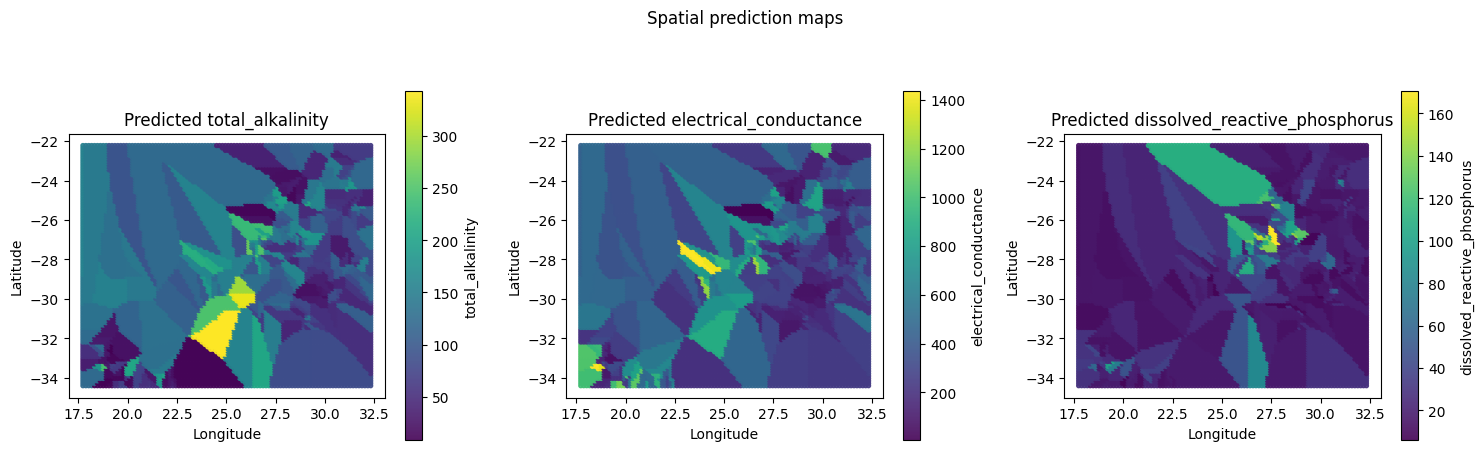

In [7]:
n_targets = len(targets_present)
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5))
if n_targets == 1:
    axes = [axes]
for ax, target in zip(axes, targets_present):
    sc = ax.scatter(grid_df["lon"], grid_df["lat"], c=grid_df[target], s=8, cmap="viridis", alpha=0.9)
    plt.colorbar(sc, ax=ax, label=target, shrink=0.8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Predicted {target}")
    ax.set_aspect("equal", adjustable="box")
plt.suptitle("Spatial prediction maps")
plt.tight_layout()
plt.show()

# 7. Interpretation

## Spatial gradients in predicted water chemistry
- Prediction maps show **spatial gradients** (smooth or patchy variation) of total alkalinity, electrical conductance, and dissolved reactive phosphorus. Gradients often follow **climate** (e.g. aridity, rainfall), **geology** (e.g. carbonate vs crystalline), and **land use** (e.g. agriculture, runoff).
- Similar spatial pattern across two or three targets may indicate **shared drivers** (e.g. evaporation concentrating salts and nutrients).

## Environmental drivers that may explain patterns
- **Elevation** and **precipitation** drive dilution and weathering; **NDVI** and **clay** relate to vegetation and soil buffering; **temperature** affects reaction rates and evaporation. The model uses these (and other) features via nearest-neighbor interpolation from sample locations to the grid, so predicted gradients reflect the learned relationship between environment and water quality at sampled sites.

## Limitations of extrapolation outside sampled regions
- Predictions are **interpolative** within the bounding box of the data; **extrapolation** beyond the sampled lat/lon range or to environments very different from the training set is uncertain.
- **Nearest-neighbor** feature assignment means grid cells inherit the feature vector of the closest sample; this does not use true spatial interpolation of each covariate (e.g. kriging) and can create step-like patterns. For research or communication, consider noting that maps are **model-based** and that validation (e.g. spatial CV) gives a more honest performance estimate than in-sample metrics.